In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [42]:
def categorize_diffusers(diffuser_coordinates, fg_coordinates, max_distance=5):
    n_diffusers = diffuser_coordinates.shape[0]
    # Initialize results array
    result = np.full((n_diffusers), "cyt", dtype='U20')
    result[diffuser_coordinates[:,2] < 0] = "nuc"
    
    # Pre-calculate total number of chains
    total_chains = sum(coords.shape[0] for coords in fg_coordinates.values())
    
    # Pre-allocate arrays for all chains
    all_min_distances = np.zeros((n_diffusers, total_chains))
    
    # Calculate minimum distances for all chains at once
    current_idx = 0
    for fg_type, coords in fg_coordinates.items():
        n_chains = coords.shape[0]
        
        # Reshape arrays for broadcasting
        chains_reshaped = coords.reshape(n_chains, -1, 3)  # [n_chains, n_beads, 3]
        diffusers_expanded = diffuser_coordinates[:, np.newaxis, np.newaxis, :]  # [n_diffusers, 1, 1, 3]
        
        # Calculate distances to all beads for all chains at once
        distances = np.linalg.norm(chains_reshaped[np.newaxis, :, :, :] - diffusers_expanded, axis=3)
        
        # Find minimum distance per chain
        all_min_distances[:, current_idx:current_idx + n_chains] = np.min(distances, axis=2)
        
        current_idx += n_chains
    
    # Process each diffuser using vectorized operations
    for i in range(n_diffusers):
        # Find valid distances within max_distance
        valid_mask = all_min_distances[i] <= max_distance
        
        if np.any(valid_mask):
            if result[i] == "nuc":
                result[i] = "nuc_bound"
            else:
                result[i] = "cyt_bound" 
    
    return result

def is_in_ct(diffuser_coordinates):
    result = (diffuser_coordinates[:, 2] <= 15) & (diffuser_coordinates[:, 2] >= -15)
    return result


def plot_integer_histogram(data, title="Integer Data Histogram", figsize=(10, 6), show_kde=True):
    """
    Create a histogram for integer data with optional KDE curve.
    
    Parameters:
    -----------
    data : array-like
        The integer data to plot
    title : str, optional
        The title of the plot (default: "Integer Data Histogram")
    figsize : tuple, optional
        Figure size as (width, height) in inches (default: (10, 6))
    show_kde : bool, optional
        Whether to show the KDE curve (default: True)
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Create the figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create histogram with automatic integer bins
    plt.hist(data, 
             bins=range(int(min(data)), int(max(data)) + 2, 1),
             color='skyblue',
             edgecolor='black',
             alpha=0.7,
             density=True)
    
    if show_kde:
        # Add a kernel density estimate (KDE) curve
        from scipy import stats
        kde = stats.gaussian_kde(data)
        x_range = np.linspace(min(data), max(data), 100)
        plt.plot(x_range, kde(x_range), 'r-', lw=2, label='KDE')
        
    
    mean_value = np.mean(data)
    conf = (np.std(data, ddof=1) / np.sqrt(len(data))) * 1.96
    plt.axvline(x=mean_value, color='red', linestyle='--', label=f'Mean: {mean_value:.2f} ± {conf:.2f}')
    plt.axvspan(mean_value - conf, mean_value + conf, alpha=0.2, color='red', label=r'SEM 97.5% confidence inerval')
    
    # fix ticks 
    bin_centers = [i + 0.5 for i in range(int(min(data)), int(max(data)) + 1)]
    ax.set_xticks(bin_centers)
    ax.set_xticklabels(range(int(min(data)), int(max(data)) + 1))
    
    # Customize the plot
    plt.suptitle(title, fontsize=14)
    plt.title("50 runs, count at 150 μs.\n Run configuration: 250 diffusers, radius 3.5 nm, 8 intearction sites")
    plt.xlabel('# of NTRs', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    
    
def plot_integer_histograms(data_list, labels=None, title="Integer Data Histograms", figsize=(10, 6), show_kde=True, colors=None):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import to_rgba
    
    # Create the figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    
    # Set default values if not provided
    if labels is None:
        labels = [f"Dataset {i+1}" for i in range(len(data_list))]
    if colors is None:
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    # Find global min and max for consistent binning
    global_min = min(min(data) for data in data_list)
    global_max = max(max(data) for data in data_list)
    bins = range(int(global_min), int(global_max) + 2, 1)
    
    # Plot each dataset
    for data, label, color in zip(data_list, labels, colors):
        # Calculate statistics
        mean_value = np.mean(data)
        conf = (np.std(data, ddof=1) / np.sqrt(len(data))) * 1.96
        
        # Create histogram
        plt.hist(data,
                bins=bins,
                color=to_rgba(color, 0.3),  # Semi-transparent fill
                edgecolor=color,
                alpha=0.7,
                density=True,
                label=f"{label} (hist)")
        
        if show_kde:
            # Add KDE curve
            from scipy import stats
            kde = stats.gaussian_kde(data)
            x_range = np.linspace(global_min, global_max, 100)
            plt.plot(x_range, kde(x_range), color=color, lw=2, 
                    label=f"{label} (KDE)")
        
        # Add mean line
        plt.axvline(x=mean_value, color=color, linestyle='--',
                    label=f"{label} mean: {mean_value:.2f} ± {conf:.2f}")
        
        # Add standard deviation region
        plt.axvspan(mean_value - conf, mean_value + conf,
                    alpha=0.1, color=color)
    
    # Set x-ticks at bin centers
    step = 5
    first_tick = int(global_min + (step - global_min % step) % step)  # First value divisible by 5
    bin_centers_all = [i + 0.5 for i in range(int(global_min), int(global_max) + 1)]
    tick_positions = range(first_tick, int(global_max) + 1, step)
    bin_centers = [i + 0.5 for i in tick_positions]
    ax.set_xticks(bin_centers)
    ax.set_xticklabels(tick_positions)
    
    # Customize the plot
    plt.title(title, fontsize=14)
    plt.xlabel('# of NTRs', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Adjust legend to prevent overlap with plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    plt.show()

In [3]:
# Counts for rod

nuc_bound = []
cyt_bound = []
nuc_unbound = []
cyt_unbound = []
in_ct = []

for i in range(1,51):
    with open(f"data/singles/{i}/150-160.pickle", "rb") as f:
        diffuser_trajectories = pickle.load(f)
    with open(f"data/singles/{i}/150-160-fgs.pickle", "rb") as f:
        fg_trajectories = pickle.load(f)
    cur_diffuser_trajectories = diffuser_trajectories[:, :, 0]
    cur_fg_trajectories = {fg_type : fg_trajectories[:, :, :, 0] for (fg_type, fg_trajectories) in fg_trajectories.items()}
    
    
    catgorized = categorize_diffusers(cur_diffuser_trajectories, cur_fg_trajectories)
    nuc_bound.append(len(np.where(catgorized == "nuc_bound")[0]))
    cyt_bound.append(len(np.where(catgorized == "cyt_bound")[0]))
    nuc_unbound.append(len(np.where(catgorized == "nuc")[0]))
    cyt_unbound.append(len(np.where(catgorized == "cyt")[0]))
    
    aaa = is_in_ct(cur_diffuser_trajectories)
    in_ct.append(len(np.where(aaa == 1)[0]))



print(nuc_bound)
print(cyt_bound)
print(nuc_unbound)
print(cyt_unbound)
print(in_ct)

[68, 68, 70, 64, 63, 66, 64, 66, 65, 69, 70, 66, 69, 64, 71, 65, 66, 67, 64, 70, 64, 62, 59, 67, 67, 70, 68, 65, 61, 65, 66, 63, 68, 70, 66, 73, 71, 64, 63, 67, 70, 68, 73, 69, 67, 66, 62, 66, 69, 65]
[92, 89, 85, 85, 84, 85, 83, 84, 83, 78, 85, 92, 88, 86, 94, 90, 90, 91, 88, 91, 87, 93, 91, 91, 89, 86, 83, 88, 94, 92, 94, 97, 91, 88, 87, 93, 90, 92, 93, 86, 91, 90, 95, 87, 88, 92, 91, 92, 93, 92]
[33, 41, 40, 47, 45, 45, 48, 42, 48, 43, 44, 42, 42, 48, 41, 38, 40, 42, 45, 35, 47, 44, 46, 43, 44, 44, 41, 48, 41, 41, 40, 43, 41, 40, 42, 41, 40, 41, 44, 43, 41, 46, 34, 46, 42, 39, 47, 45, 42, 42]
[57, 52, 55, 54, 58, 54, 55, 58, 54, 60, 51, 50, 51, 52, 44, 57, 54, 50, 53, 54, 52, 51, 54, 49, 50, 50, 58, 49, 54, 52, 50, 47, 50, 52, 55, 43, 49, 53, 50, 54, 48, 46, 48, 48, 53, 53, 50, 47, 46, 51]
[51, 52, 46, 52, 49, 52, 48, 48, 49, 48, 48, 44, 48, 55, 54, 53, 52, 48, 49, 49, 51, 53, 47, 55, 54, 51, 47, 46, 56, 50, 51, 52, 50, 49, 50, 54, 52, 48, 48, 51, 52, 48, 55, 51, 53, 52, 51, 49, 48,

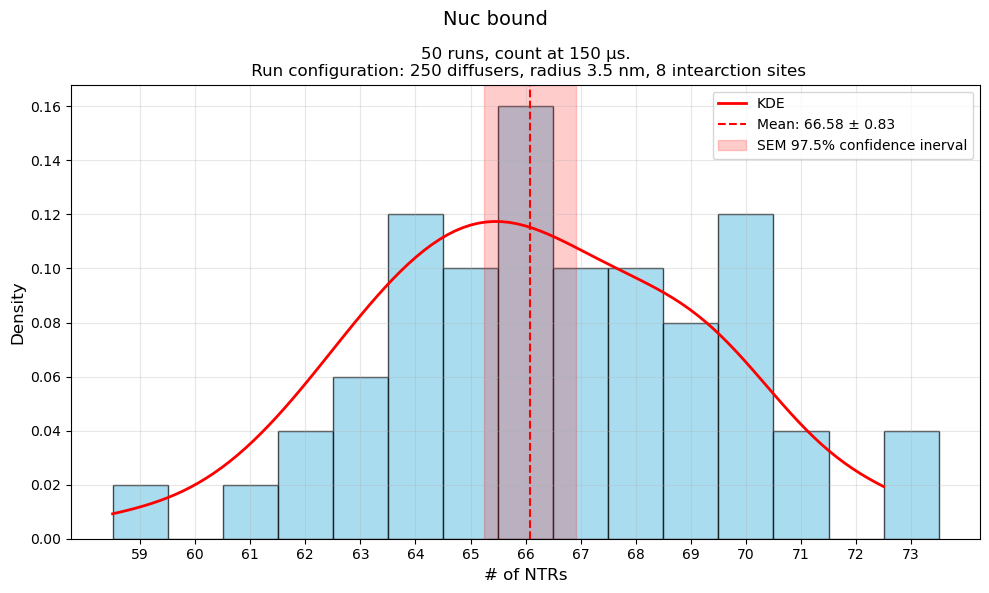

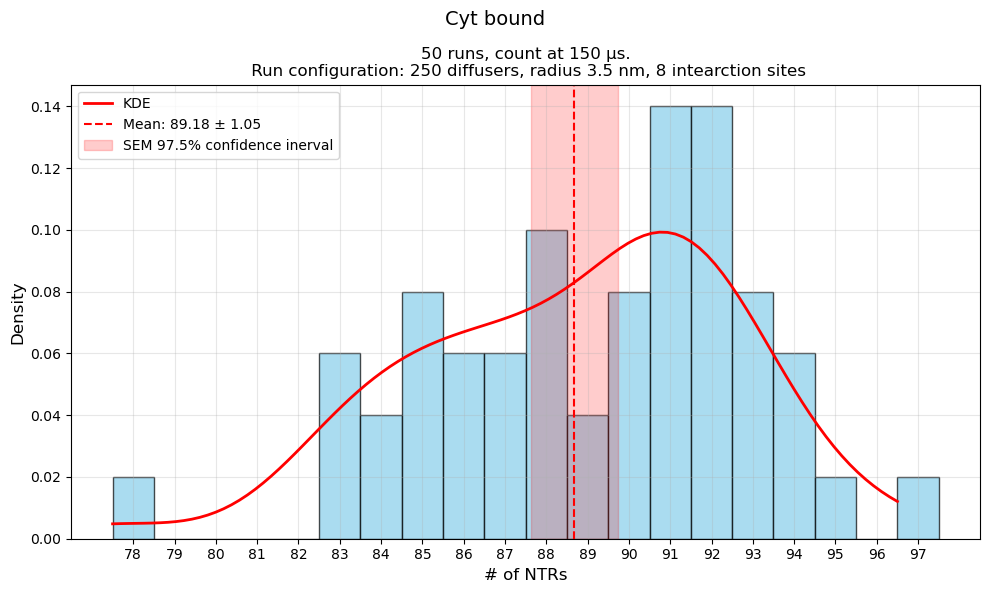

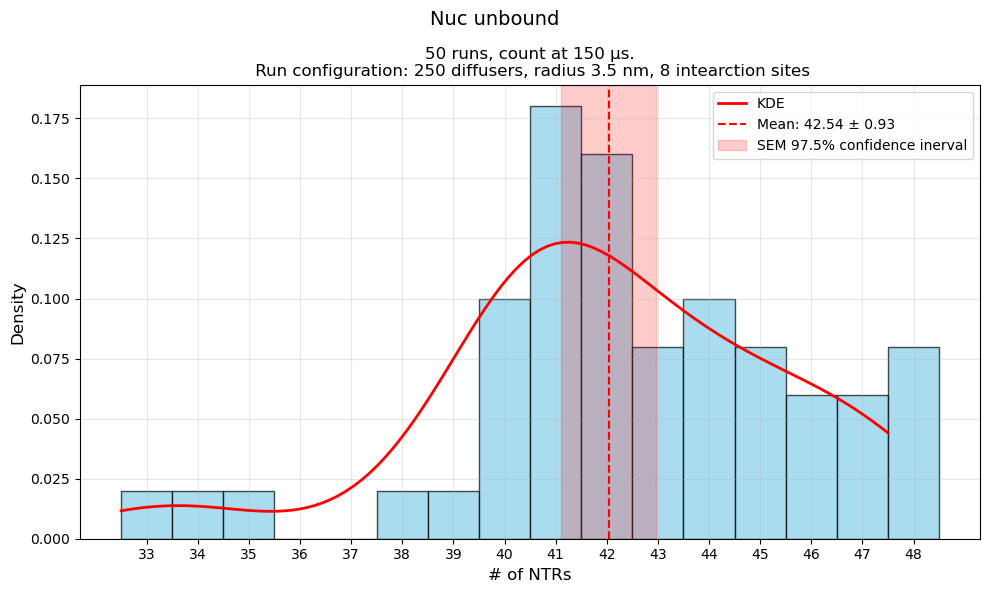

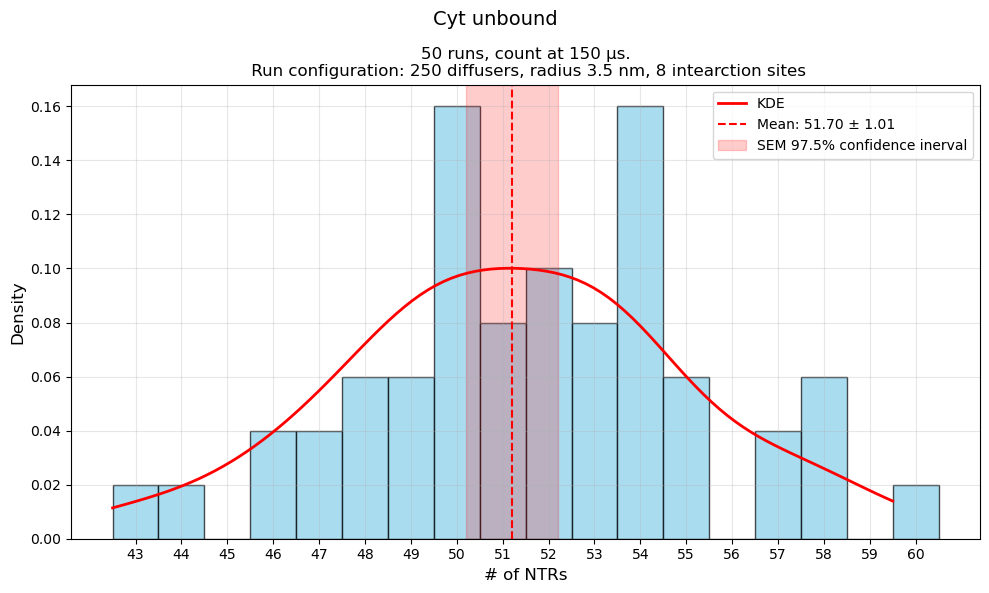

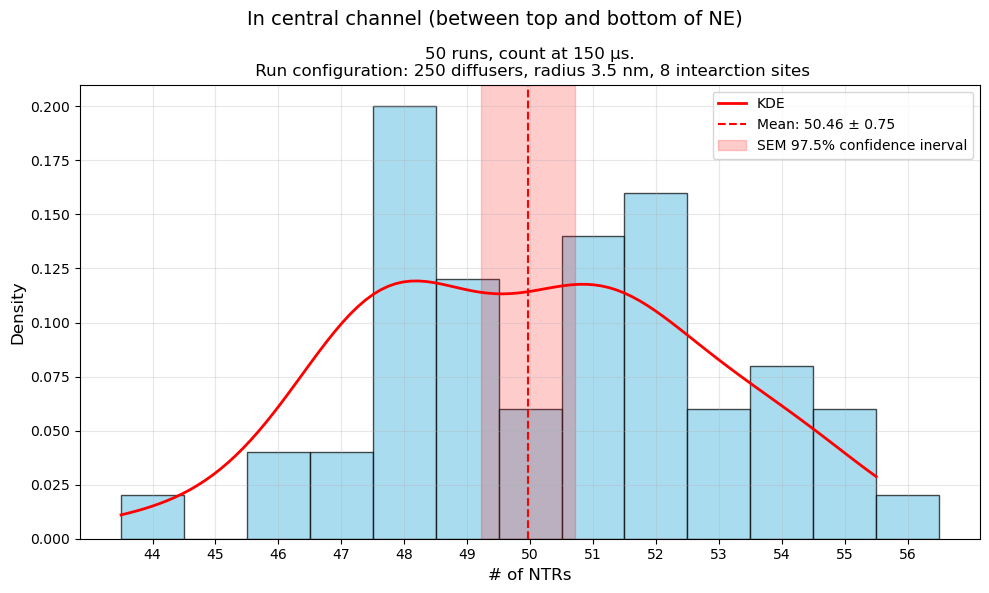

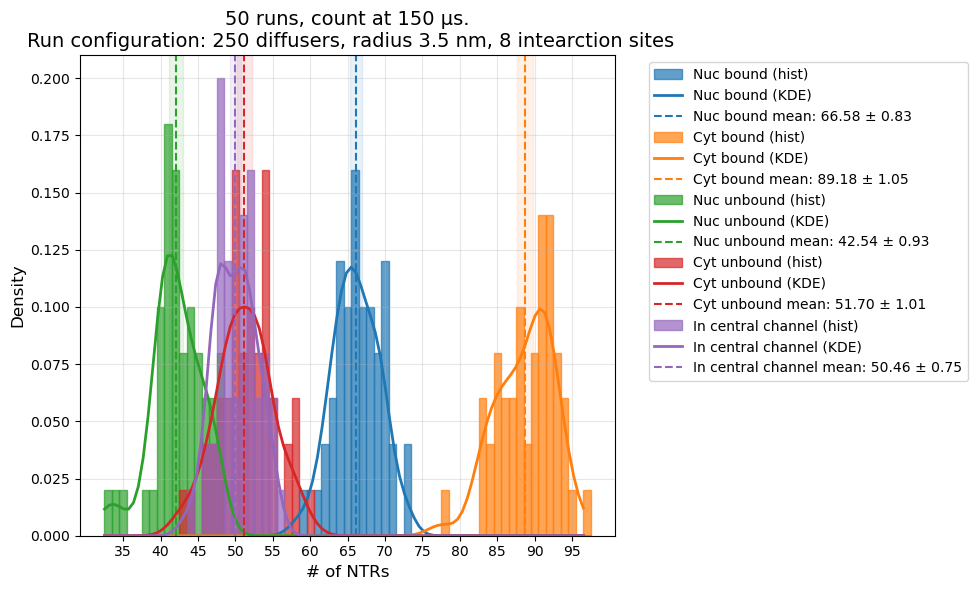

In [44]:
plot_integer_histogram(nuc_bound, "Nuc bound")
plot_integer_histogram(cyt_bound, "Cyt bound")
plot_integer_histogram(nuc_unbound, "Nuc unbound")
plot_integer_histogram(cyt_unbound, "Cyt unbound")
plot_integer_histogram(in_ct, "In central channel (between top and bottom of NE)")
plot_integer_histograms([nuc_bound, cyt_bound, nuc_unbound, cyt_unbound, in_ct],
                        ["Nuc bound", "Cyt bound", "Nuc unbound", "Cyt unbound", "In central channel"],
                        title="50 runs, count at 150 μs.\n Run configuration: 250 diffusers, radius 3.5 nm, 8 intearction sites")
